# Lab 11. More `plotly` chart examples and Principal Component Analysis (PCA)

## 1. A few other examples of charts with the `plotly` library

In [1]:
# install if the library is missing
import plotly as py
import datetime
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from ipywidgets import widgets

### 1.1 Example of interactive charts

> **NOTE!**  
> The following examples illustrate the possible use of iPyWidgets and plotly to create interactive charts in Jupyter Notebook,
> however, they do not always work correctly for reasons as yet unexplained.
>
> List of controls: https://ipywidgets.readthedocs.io/en/stable/examples/Widget%20List.html#date-picker

In [3]:
# loading the dataset
df = pd.read_csv('./data/orders.csv', sep=';')
# date column conversion
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df.head()

,Country,Seller,OrderDate,OrderId,OrderValue
0,Polska,Kowalski,2003-07-16,10248,440.00
1,Polska,Sowiński,2003-07-10,10249,1863.40
2,Niemcy,Peacock,2003-07-12,10250,1552.60
3,Niemcy,Leverling,2003-07-15,10251,654.06
4,Niemcy,Peacock,2003-07-11,10252,3597.90


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 799 entries, 0 to 798
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Country     799 non-null    str           
 1   Seller      799 non-null    str           
 2   OrderDate   799 non-null    datetime64[us]
 3   OrderId     799 non-null    int64         
 4   OrderValue  799 non-null    float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 31.3 KB


In [5]:

country_widget = widgets.Dropdown(
    options=list(df['Country'].unique()),
    value=df['Country'][0],
    description='Country:',
)
 

seller_widget = widgets.Dropdown(
    description='Seller:   ',
    value=df[df['Country'] == country_widget.value]['Seller'][0],
    options=df[df['Country'] == country_widget.value]['Seller'].unique().tolist()
)


trace2 = go.Histogram(x=df['OrderValue'], opacity=0.75, name='Revenue distribution')
g1 = go.FigureWidget(data=[trace2],
                    layout=go.Layout(
                        title=dict(
                            text='Sales'
                        ),
                        barmode='overlay'
                    ))

In [7]:
def validate():
    if country_widget.value in df['Country'].unique() and seller_widget.value in df['Seller'].unique():
        return True
    else:
        return False


def response(change):
    # update values for seller
    seller_widget.options = df[df['Country'] == country_widget.value]['Seller'].unique().tolist()
    if validate():
        data = df[(df['Seller'] == seller_widget.value) & (df['Country'] == country_widget.value)]
        with g1.batch_update():
            g1.data[0].x = data['OrderValue']
            # g.layout.xaxis = 'Etykieta'
            # g.layour.yaxis = 'Etykieta'

# adding listening for value change in controls
country_widget.observe(response, names="value")
seller_widget.observe(response, names="value")

In [8]:
g1

FigureWidget({
    'data': [{'name': 'Rozkład utargu',
              'opacity': 0.75,
              'type': 'histogram',
              'uid': '6f36ee85-fec2-4fff-88d9-7463c71c0226',
              'x': {'bdata': ('AAAAAACAe0CamZmZmR2dQGZmZmZmQp' ... 'AAAN6nQAAAAAAAOK1AAAAAAACARkA='),
                    'dtype': 'f8'}}],
    'layout': {'barmode': 'overlay', 'template': '...', 'title': {'text': 'Sprzedaż'}}
})

In [ ]:
# placing widgets into a container
container2 = widgets.HBox([country_widget, seller_widget])
widgets.VBox([container2, g1])

In [10]:
# the data that will be presented on the chart is the cumulative sum of order values by date
plot_data = df[['Country', 'OrderDate','OrderValue']].groupby(['Country', 'OrderDate']).agg({'OrderValue': 'sum'}).cumsum()
plot_data = plot_data.reset_index()
plot_data

,Country,OrderDate,OrderValue
0,Niemcy,2003-07-11,3597.90
1,Niemcy,2003-07-12,5150.50
2,Niemcy,2003-07-15,5804.56
3,Niemcy,2003-07-16,7249.36
4,Niemcy,2003-07-17,7767.16
...,...,...,...
500,Polska,2005-04-24,1214099.48
501,Polska,2005-04-27,1226774.53
502,Polska,2005-04-29,1226984.53
503,Polska,2005-04-30,1227509.53


In [11]:
# widgets declaration

country_widget = widgets.Dropdown(
    options=list(plot_data['Country'].unique()),
    value=plot_data['Country'][0],
    description='Country:',
)

# chart declaration
fig = go.Scatter(x=plot_data['OrderValue'], name='Cumulative revenue', mode='lines')

g2 = go.FigureWidget(data=[fig],
                    layout=go.Layout(
                        title=dict(
                            text='Sales skumulowana'
                        ),
                        barmode='overlay'
                    ))

# function validating the correctness of data in the controls
def validate():
    if country_widget.value in plot_data['Country'].unique():
        return True
    else:
        return False

# function run when the control state changes (updates the chart)
def response(change):
    if validate():
        dat = plot_data[plot_data['Country'] == country_widget.value]
        with g2.batch_update():
            g2.data[0].x = dat['OrderValue']
            # g.layout.xaxis = 'Data'
            # g.layour.yaxis = 'Order value'


country_widget.observe(response, names="value")

In [12]:
g2

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'Skumulowany utarg',
              'type': 'scatter',
              'uid': '37361c28-8b19-441a-bbe8-bff1c0695fde',
              'x': {'bdata': ('zczMzMwbrEAAAAAAgB60QML1KFyPrL' ... '6H6LgyQX0Urof1ujJBaWZmZie+MkE='),
                    'dtype': 'f8'}}],
    'layout': {'barmode': 'overlay', 'template': '...', 'title': {'text': 'Sprzedaż skumulowana'}}
})

In [13]:
container = widgets.HBox([country_widget])
widgets.VBox([container, g2])

## 2. Principal Component Analysis (PCA)

In [ ]:
!pip install scikit-learn

In [16]:
# use of dimensionality reduction examples from the lecture

# adding visualization of selected features to show their distribution for analysis
# but maybe also to make a choice of dimensionality reduction mechanism

# calculating variance to also indicate it

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA, KernelPCA

In [17]:
# loading the dataset iris

iris = load_iris()
feature_names = iris.feature_names
feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

**First, we will perform linear dimensionality reduction**

In [18]:
pca = PCA(n_components=2)        # reduction to 2 dimensions
reduced = pca.fit_transform(iris.data)

In [19]:
# original shape (rows, columns/features) vs. after dimension reduction
iris.data.shape, reduced.shape

((150, 4), (150, 2))

In [20]:
# what the calculated variance for the returned features looks like
pca.explained_variance_ratio_

array([0.92461872, 0.05306648])

In [22]:
# collectively it will turn out that these two features describe almost 98% of the variability from this data
sum(pca.explained_variance_ratio_)

np.float64(0.9776852063187963)

In [23]:
# what the new set of features looks like
pca.get_feature_names_out()

array(['pca0', 'pca1'], dtype=object)

**Another example**

In [24]:
# merging data from the iris set with scikit learn into a dataframe
iris_df = pd.DataFrame(np.hstack([iris.data, np.expand_dims(iris.target, axis=1)]), columns=iris.feature_names + ['target'])

In [25]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [26]:
pca = PCA(n_components=.99)        # reduction to a minimum level of 99% of preserved variance
# pca.feature_names_in_ = iris_df.columns[:-1]
reduced = pca.fit_transform(iris_df[iris_df.columns[:-1]], iris_df[iris_df.columns[-1]])  

In [27]:
# original shape (rows, columns/features) vs. after dimension reduction
iris.data.shape, reduced.shape

((150, 4), (150, 3))

In [28]:
pca.explained_variance_ratio_

array([0.92461872, 0.05306648, 0.01710261])

In [29]:
# collectively it will turn out that these two features describe almost 99.5% of the variability from this data
sum(pca.explained_variance_ratio_)

np.float64(0.9947878161267253)

In [30]:
# feature names in the output set (but that tells us little)
pca.get_feature_names_out()

array(['pca0', 'pca1', 'pca2'], dtype=object)

In [31]:
# number of input features
pca.n_features_in_

4

In [32]:
# components of each new set dimension (n_components × n_features_in)
pca.components_

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102],
       [-0.58202985,  0.59791083,  0.07623608,  0.54583143]])

In [33]:
# summary weight of each feature
np.sum(np.abs(pca.components_), axis=0)

array([1.60000521, 1.41259478, 1.10627934, 0.97960165])

It turns out that the `petal width` feature is characterized by the smallest weight and should be rejected first. The next would be the `petal length` feature, etc.

We can also calculate this from the data calculated by the PCA algorithm.

In [34]:
# sorting features from most important to least important in the context of the measure used by the PCA algorithm
features_order = np.argsort(np.sum(np.abs(pca.components_), axis=0))[::-1]

In [35]:
pca.feature_names_in_[features_order].tolist()

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

OK, we see that PCA reduced the dimension of features in the set automatically based on variance by rejecting one feature. The reduction of the number of features continues as long as the removal of the next feature does not fall below the assumed threshold of summary variance. But how is it with the intuition of linear dimension reduction?

Let's look at the plot below, which presents a matrix of the distribution of decision class values (species, our target) for each feature of the set. If we find such features whose points for the decision class do not overlap if we projected them onto a line (because here we have 2 dimensions, we project onto 1 dimension), which means they are linearly separable, then the linear PCA algorithm will certainly choose them as the first to be rejected.

In [36]:
import plotly.express as px

df = px.data.iris()
features = ["sepal_width", "sepal_length", "petal_width", "petal_length"]

fig = px.scatter_matrix(
    df,
    dimensions=features,
    color="species"
)
fig.update_traces(diagonal_visible=False)
fig.show()

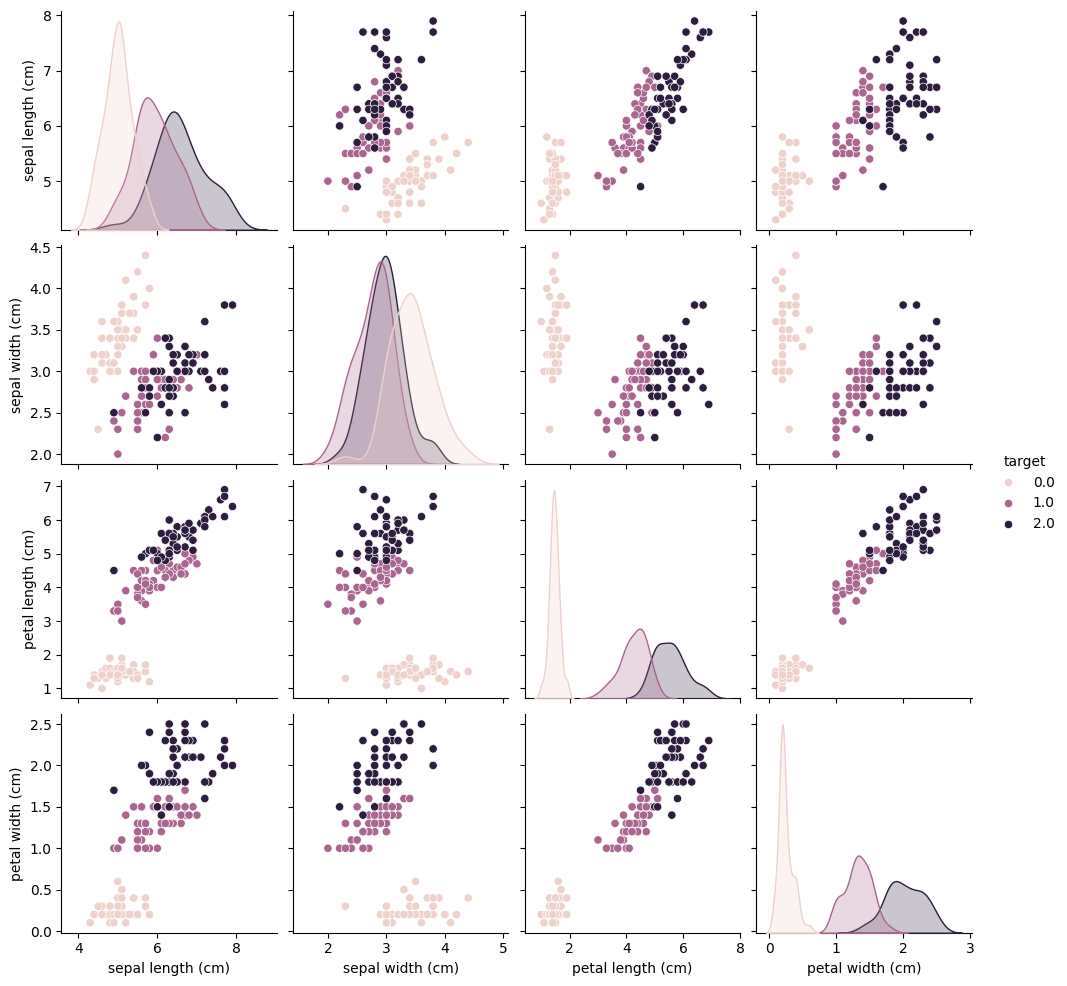

In [37]:
# the same (almost) plot, but using the seaborn library
import seaborn as sns

# Rename classes using the iris target names
_ = sns.pairplot(iris_df, hue="target")

**We display the same type of plot again for the new features of the set after dimensionality reduction**

In [38]:
reduced_df = pd.DataFrame(np.hstack([reduced, np.expand_dims(iris_df.iloc[:, -1], axis=1)]))
reduced_df.head()

,0,1,2,3
0,-2.684126,0.319397,-0.027915,0.0
1,-2.714142,-0.177001,-0.210464,0.0
2,-2.888991,-0.144949,0.017900,0.0
3,-2.745343,-0.318299,0.031559,0.0
4,-2.728717,0.326755,0.090079,0.0


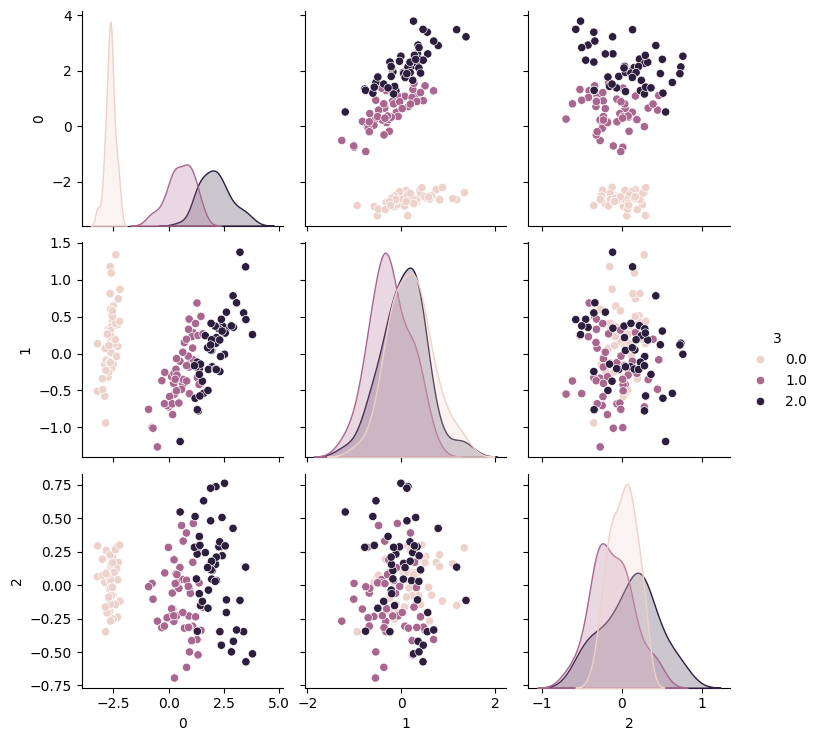

In [39]:
_ = sns.pairplot(reduced_df, hue=3)

## Tasks

**Task 1**

Using any dataset from the EUROSTAT set, display one of the numerical features in the form of a chart with a map from the example in this lab. You must map country names, because in the chart parameters and EUROSTAT data these names differ a bit. A link to the file that will facilitate this is in the comment in the code of the example chart with a map.

**Task 2**

Using the wine dataset from the sklearn library (`load_wine()`), similarly to the iris set), perform PCA analysis so that:
* maintain a minimum of 99% variance
* maintain a minimum of 95% variance
* maintain a minimum of 90% variance

How many features remained in these sets?

**Task 3**  

Using the example in the lab, generate a correlation plot of feature values relative to the decision class (target) shown in the lab (scatter plot). Were the features that PCA rejected actually indicated as the best candidates in terms of linear separability?

In [15]:
# a dictionary with all country names mappings - to make things easier in the eurostat dataset
countries = {"BD": "BGD", "BE": "BEL", "BF": "BFA", "BG": "BGR", "BA": "BIH", "BB": "BRB", "WF": "WLF", "BL": "BLM", "BM": "BMU", "BN": "BRN", "BO": "BOL", "BH": "BHR", "BI": "BDI", "BJ": "BEN", "BT": "BTN", "JM": "JAM", "BV": "BVT", "BW": "BWA", "WS": "WSM", "BQ": "BES", "BR": "BRA", "BS": "BHS", "JE": "JEY", "BY": "BLR", "BZ": "BLZ", "RU": "RUS", "RW": "RWA", "RS": "SRB", "TL": "TLS", "RE": "REU", "TM": "TKM", "TJ": "TJK", "RO": "ROU", "TK": "TKL", "GW": "GNB", "GU": "GUM", "GT": "GTM", "GS": "SGS", "GR": "GRC", "GQ": "GNQ", "GP": "GLP", "JP": "JPN", "GY": "GUY", "GG": "GGY", "GF": "GUF", "GE": "GEO", "GD": "GRD", "GB": "GBR", "GA": "GAB", "SV": "SLV", "GN": "GIN", "GM": "GMB", "GL": "GRL", "GI": "GIB", "GH": "GHA", "OM": "OMN", "TN": "TUN", "JO": "JOR", "HR": "HRV", "HT": "HTI", "HU": "HUN", "HK": "HKG", "HN": "HND", "HM": "HMD", "VE": "VEN", "PR": "PRI", "PS": "PSE", "PW": "PLW", "PT": "PRT", "SJ": "SJM", "PY": "PRY", "IQ": "IRQ", "PA": "PAN", "PF": "PYF", "PG": "PNG", "PE": "PER", "PK": "PAK", "PH": "PHL", "PN": "PCN", "PL": "POL", "PM": "SPM", "ZM": "ZMB", "EH": "ESH", "EE": "EST", "EG": "EGY", "ZA": "ZAF", "EC": "ECU", "IT": "ITA", "VN": "VNM", "SB": "SLB", "ET": "ETH", "SO": "SOM", "ZW": "ZWE", "SA": "SAU", "ES": "ESP", "ER": "ERI", "ME": "MNE", "MD": "MDA", "MG": "MDG", "MF": "MAF", "MA": "MAR", "MC": "MCO", "UZ": "UZB", "MM": "MMR", "ML": "MLI", "MO": "MAC", "MN": "MNG", "MH": "MHL", "MK": "MKD", "MU": "MUS", "MT": "MLT", "MW": "MWI", "MV": "MDV", "MQ": "MTQ", "MP": "MNP", "MS": "MSR", "MR": "MRT", "IM": "IMN", "UG": "UGA", "TZ": "TZA", "MY": "MYS", "MX": "MEX", "IL": "ISR", "FR": "FRA", "IO": "IOT", "SH": "SHN", "FI": "FIN", "FJ": "FJI", "FK": "FLK", "FM": "FSM", "FO": "FRO", "NI": "NIC", "NL": "NLD", "NO": "NOR", "NA": "NAM", "VU": "VUT", "NC": "NCL", "NE": "NER", "NF": "NFK", "NG": "NGA", "NZ": "NZL", "NP": "NPL", "NR": "NRU", "NU": "NIU", "CK": "COK", "XK": "XKX", "CI": "CIV", "CH": "CHE", "CO": "COL", "CN": "CHN", "CM": "CMR", "CL": "CHL", "CC": "CCK", "CA": "CAN", "CG": "COG", "CF": "CAF", "CD": "COD", "CZ": "CZE", "CY": "CYP", "CX": "CXR", "CR": "CRI", "CW": "CUW", "CV": "CPV", "CU": "CUB", "SZ": "SWZ", "SY": "SYR", "SX": "SXM", "KG": "KGZ", "KE": "KEN", "SS": "SSD", "SR": "SUR", "KI": "KIR", "KH": "KHM", "KN": "KNA", "KM": "COM", "ST": "STP", "SK": "SVK", "KR": "KOR", "SI": "SVN", "KP": "PRK", "KW": "KWT", "SN": "SEN", "SM": "SMR", "SL": "SLE", "SC": "SYC", "KZ": "KAZ", "KY": "CYM", "SG": "SGP", "SE": "SWE", "SD": "SDN", "DO": "DOM", "DM": "DMA", "DJ": "DJI", "DK": "DNK", "VG": "VGB", "DE": "DEU", "YE": "YEM", "DZ": "DZA", "US": "USA", "UY": "URY", "YT": "MYT", "UM": "UMI", "LB": "LBN", "LC": "LCA", "LA": "LAO", "TV": "TUV", "TW": "TWN", "TT": "TTO", "TR": "TUR", "LK": "LKA", "LI": "LIE", "LV": "LVA", "TO": "TON", "LT": "LTU", "LU": "LUX", "LR": "LBR", "LS": "LSO", "TH": "THA", "TF": "ATF", "TG": "TGO", "TD": "TCD", "TC": "TCA", "LY": "LBY", "VA": "VAT", "VC": "VCT", "AE": "ARE", "AD": "AND", "AG": "ATG", "AF": "AFG", "AI": "AIA", "VI": "VIR", "IS": "ISL", "IR": "IRN", "AM": "ARM", "AL": "ALB", "AO": "AGO", "AQ": "ATA", "AS": "ASM", "AR": "ARG", "AU": "AUS", "AT": "AUT", "AW": "ABW", "IN": "IND", "AX": "ALA", "AZ": "AZE", "IE": "IRL", "ID": "IDN", "UA": "UKR", "QA": "QAT", "MZ": "MOZ"}

In [108]:
type(countries)

dict

In [109]:
countries['DE']

'DEU'